In [2]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.preprocess import (
    load_data,
    clean_data,
    encode_data,
    split_features_target
)

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [3]:
df = load_data("../data/agaricus-lepiota.data")
df = clean_data(df)
df, encoders = encode_data(df)
X, y = split_features_target(df)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6499, 22)
(1625, 22)


In [5]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [6]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [7]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [8]:
def evaluate_model(name, y_true, y_pred):
    print("="*50)
    print(name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

In [9]:
evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    pred_xgb
)

Logistic Regression
Accuracy : 0.9587692307692308
Precision: 0.9637305699481865
Recall   : 0.9501915708812261
F1-score : 0.9569131832797427
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       842
           1       0.96      0.95      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

         

In [10]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [11]:
print(grid.best_params_)
best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)

print(classification_report(
    y_test,
    pred_best
))

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [12]:
result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Optimized RF"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb),
        accuracy_score(y_test,pred_best)
    ],
    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_xgb),
        precision_score(y_test,pred_best)
    ],
    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_xgb),
        recall_score(y_test,pred_best)
    ],
    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_xgb),
        f1_score(y_test,pred_best)
    ]
})

result

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.958769,0.963731,0.950192,0.956913
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,XGBoost,1.000000,1.000000,1.000000,1.000000
3,Optimized RF,1.000000,1.000000,1.000000,1.000000


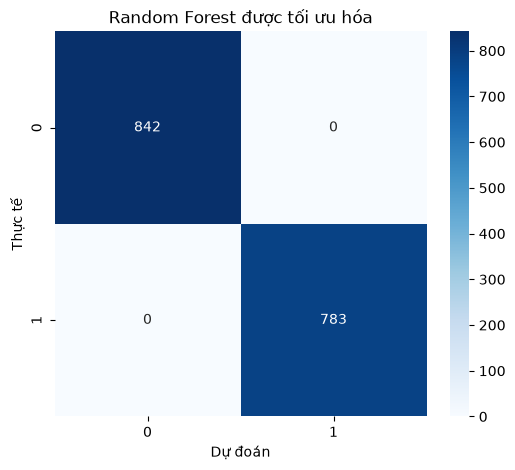

In [13]:
cm = confusion_matrix(
    y_test,
    pred_best
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Random Forest được tối ưu hóa")
plt.show()

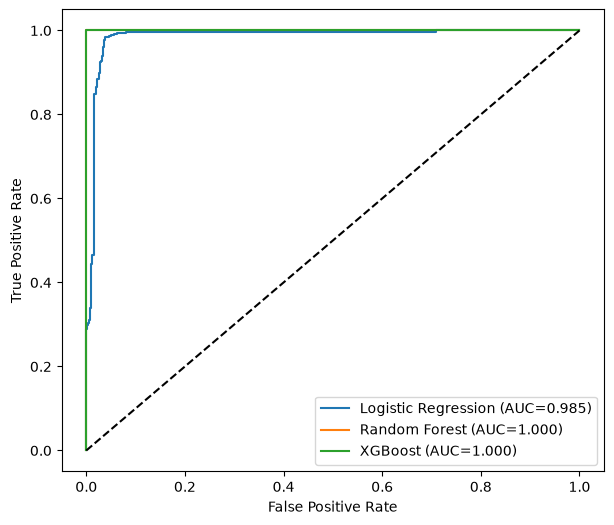

In [14]:
plt.figure(figsize=(7,6))
models = {
    "Logistic Regression":lr,
    "Random Forest":rf,
    "XGBoost":xgb
}
for name,model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,prob)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [15]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,odor,0.179867
8,gill_color,0.122870
7,gill_size,0.113607
19,spore_print_color,0.102116
18,ring_type,0.065316
20,population,0.061165
10,stalk_root,0.054003
11,stalk_surface_above_ring,0.050782
3,bruises,0.044802
21,habitat,0.033251


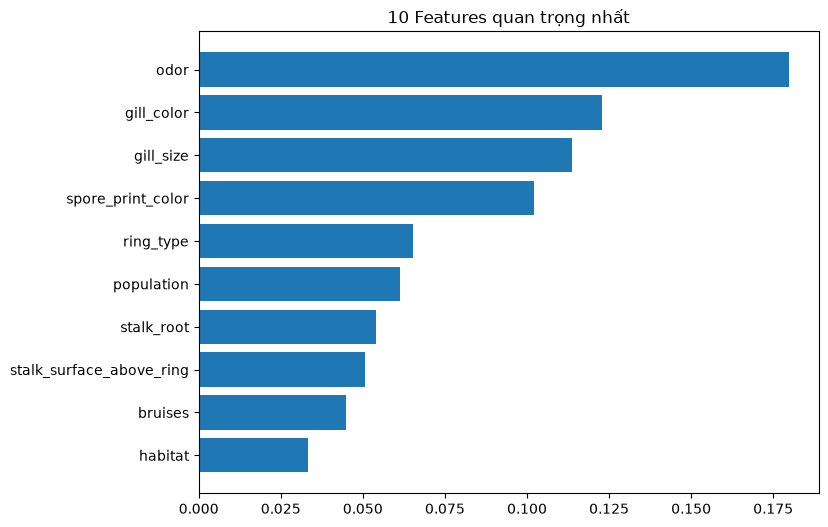

In [16]:
plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("10 Features quan trọng nhất")
plt.show()

In [17]:
joblib.dump(
    best_rf,
    "../models/best_model.pkl"
)
joblib.dump(
    encoders,
    "../models/encoders.pkl"
)
print("Lưu thành công.")

Lưu thành công.


In [18]:
print(encoders["poisonous"].classes_)

['e' 'p']
